In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv('Downloads/archive (2)/complete.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4692, 10)


In [6]:
df.head()

,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4692 entries, 0 to 4691
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       4692 non-null   object 
 1   Name of State / UT         4692 non-null   object 
 2   Latitude                   4692 non-null   float64
 3   Longitude                  4692 non-null   float64
 4   Total Confirmed cases      4692 non-null   float64
 5   Death                      4692 non-null   object 
 6   Cured/Discharged/Migrated  4692 non-null   float64
 7   New cases                  4692 non-null   int64  
 8   New deaths                 4692 non-null   int64  
 9   New recovered              4692 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 366.7+ KB


In [8]:
df.describe()

,Latitude,Longitude,Total Confirmed cases,Cured/Discharged/Migrated,New cases,New deaths,New recovered
count,4692.000000,4692.000000,4692.000000,4692.000000,4692.000000,4692.0,4692.000000
mean,23.185327,81.451837,11393.925192,6908.130648,418.643009,0.0,283.069054
std,6.635913,6.959475,37208.600846,23390.671258,1259.748923,0.0,947.925811
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,-1.000000
25%,18.112400,76.271100,39.000000,9.000000,1.000000,0.0,0.000000
50%,23.940800,79.019300,619.000000,197.500000,26.000000,0.0,8.000000
75%,28.218000,85.313100,5233.000000,2736.000000,210.250000,0.0,119.000000
max,34.299600,94.727800,468265.000000,305521.000000,18366.000000,0.0,13401.000000


In [9]:
df.isnull().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [10]:
# Top 10 states with highest confirmed cases
top10 = df.groupby('Name of State / UT')['Total Confirmed cases'].max().sort_values(ascending=False).head(10)
print(top10)

Name of State / UT
Maharashtra       468265.0
Tamil Nadu        273460.0
Andhra Pradesh    186461.0
Karnataka         151449.0
Delhi             140232.0
Uttar Pradesh     104388.0
West Bengal        83800.0
Telangana          73050.0
Gujarat            66669.0
Bihar              64770.0
Name: Total Confirmed cases, dtype: float64


C:\Users\ramya.u\AppData\Local\Temp\ipykernel_2072\469690049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')


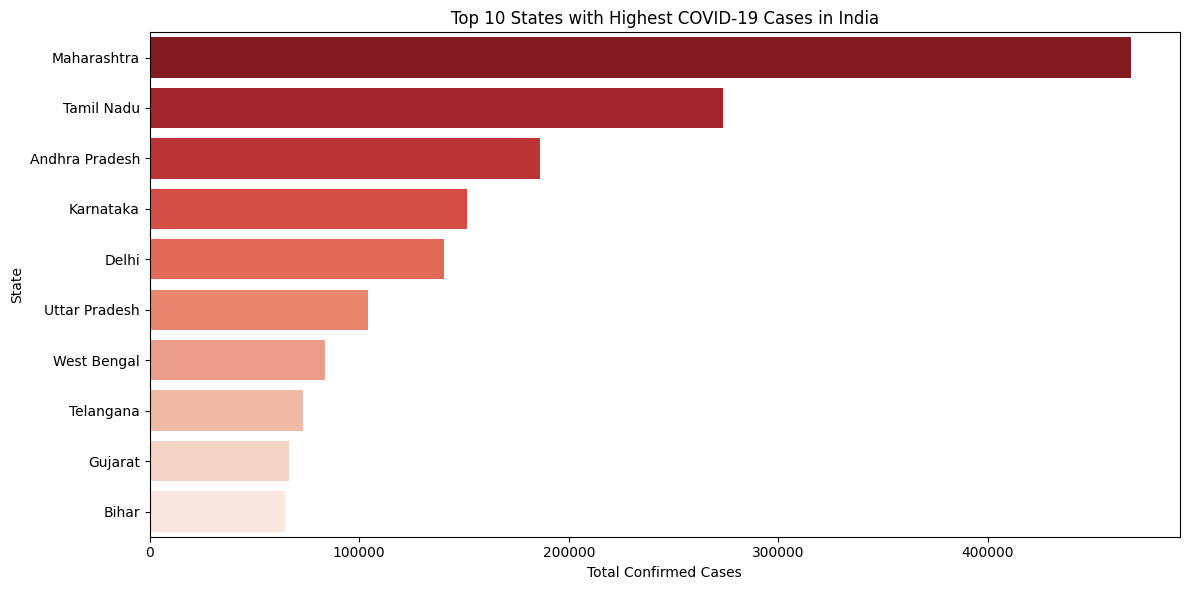

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.title('Top 10 States with Highest COVID-19 Cases in India')
plt.xlabel('Total Confirmed Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()

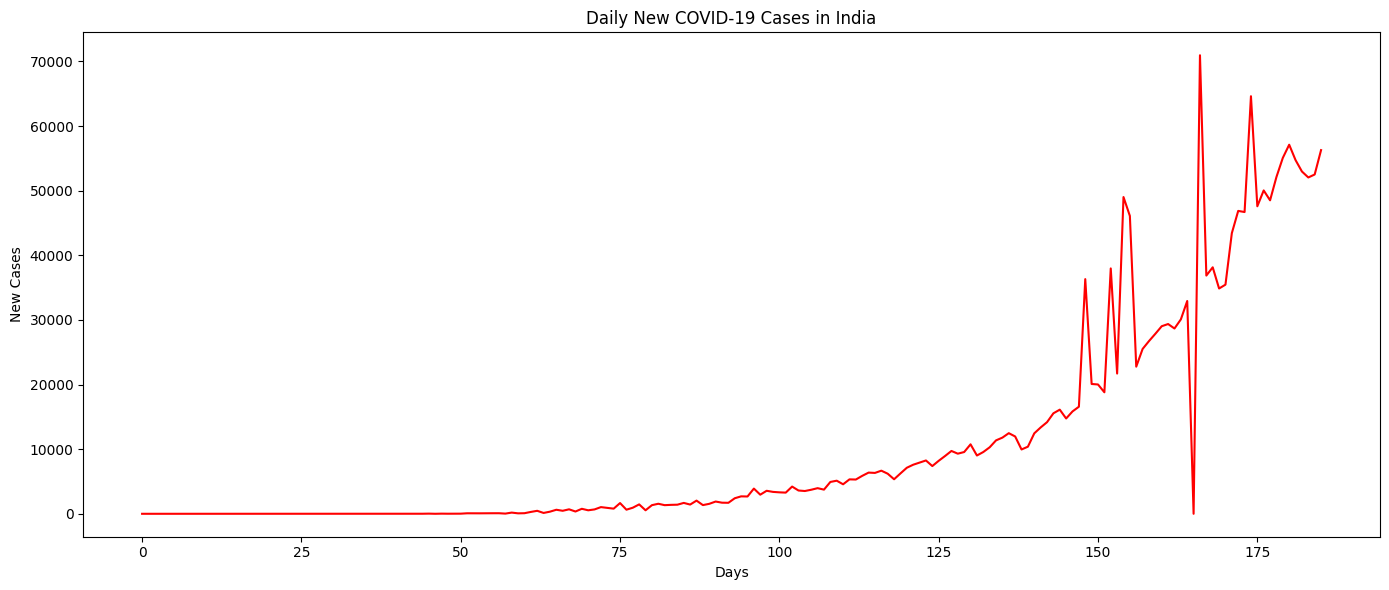

In [12]:
# Daily new cases trend in India
daily = df.groupby('Date')['New cases'].sum()
plt.figure(figsize=(14,6))
plt.plot(daily.values, color='red')
plt.title('Daily New COVID-19 Cases in India')
plt.xlabel('Days')
plt.ylabel('New Cases')
plt.tight_layout()
plt.show()

In [13]:
# Top 10 states with highest deaths
top10_deaths = df.groupby('Name of State / UT')['New deaths'].max().sort_values(ascending=False).head(10)
print(top10_deaths)

Name of State / UT
Andaman and Nicobar Islands    0
Andhra Pradesh                 0
Mizoram                        0
Nagaland                       0
Odisha                         0
Puducherry                     0
Punjab                         0
Rajasthan                      0
Sikkim                         0
Tamil Nadu                     0
Name: New deaths, dtype: int64


In [14]:
# Recovery rate by state
df['Recovery Rate'] = (df['Cured/Discharged/Migrated'] / df['Total Confirmed cases']) * 100
top_recovery = df.groupby('Name of State / UT')['Recovery Rate'].mean().sort_values(ascending=False).head(10)
print(top_recovery)

Name of State / UT
Telangana***                   76.876453
Andaman and Nicobar Islands    65.910419
Telangana                      60.188459
Ladakh                         58.356083
Chhattisgarh                   55.327994
Goa                            51.358166
Tripura                        51.009826
Chandigarh                     50.506774
Himachal Pradesh               48.892750
Haryana                        48.118131
Name: Recovery Rate, dtype: float64


C:\Users\ramya.u\AppData\Local\Temp\ipykernel_2072\1205724429.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_recovery.values, y=top_recovery.index, palette='Greens_r')


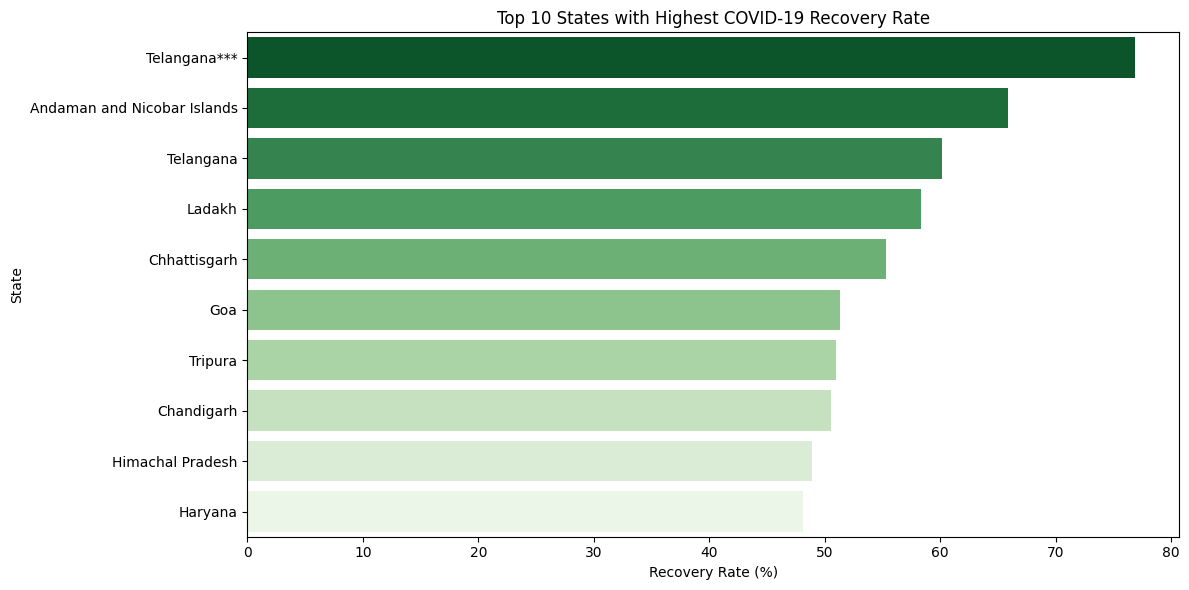

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_recovery.values, y=top_recovery.index, palette='Greens_r')
plt.title('Top 10 States with Highest COVID-19 Recovery Rate')
plt.xlabel('Recovery Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

C:\Users\ramya.u\AppData\Local\Temp\ipykernel_2072\3005615466.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly.index, y=monthly.values, palette='Blues_r')


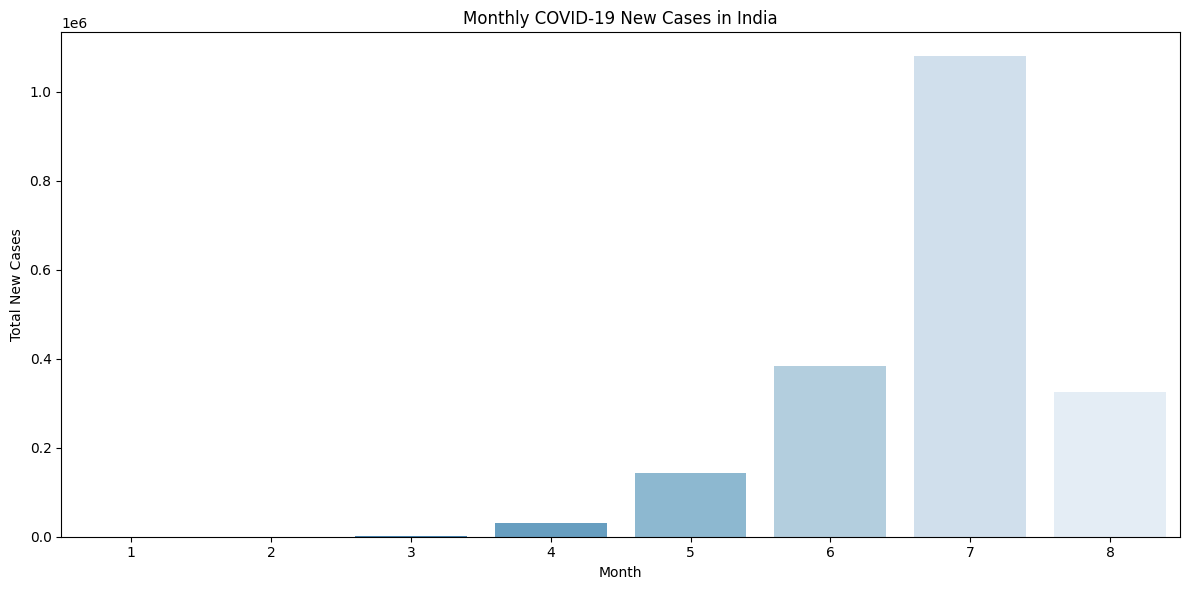

In [16]:
# Monthly trend of new cases
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
monthly = df.groupby('Month')['New cases'].sum()

plt.figure(figsize=(12,6))
sns.barplot(x=monthly.index, y=monthly.values, palette='Blues_r')
plt.title('Monthly COVID-19 New Cases in India')
plt.xlabel('Month')
plt.ylabel('Total New Cases')
plt.tight_layout()
plt.show()

In [17]:
print("=" * 50)
print("EDA SUMMARY - COVID-19 INDIA DATASET")
print("=" * 50)
print(f"Total Records: {df.shape[0]}")
print(f"Total States/UTs: {df['Name of State / UT'].nunique()}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Most Affected State: Maharashtra (468,265 cases)")
print(f"Highest Recovery Rate: Telangana (76.87%)")
print("=" * 50)
print("EDA Completed Successfully!")

EDA SUMMARY - COVID-19 INDIA DATASET
Total Records: 4692
Total States/UTs: 40
Date Range: 2020-01-30 00:00:00 to 2020-08-06 00:00:00
Most Affected State: Maharashtra (468,265 cases)
Highest Recovery Rate: Telangana (76.87%)
EDA Completed Successfully!
